#Project for Power Demand Forecasting 

In [16]:
#EDA, Handling extremities, Imputation and Zooming in on a week to check for trends

Duplicate timestamps :  432
Missing values :  0


Text(0.5, 1.0, 'First Week of 2024 zoomed in')

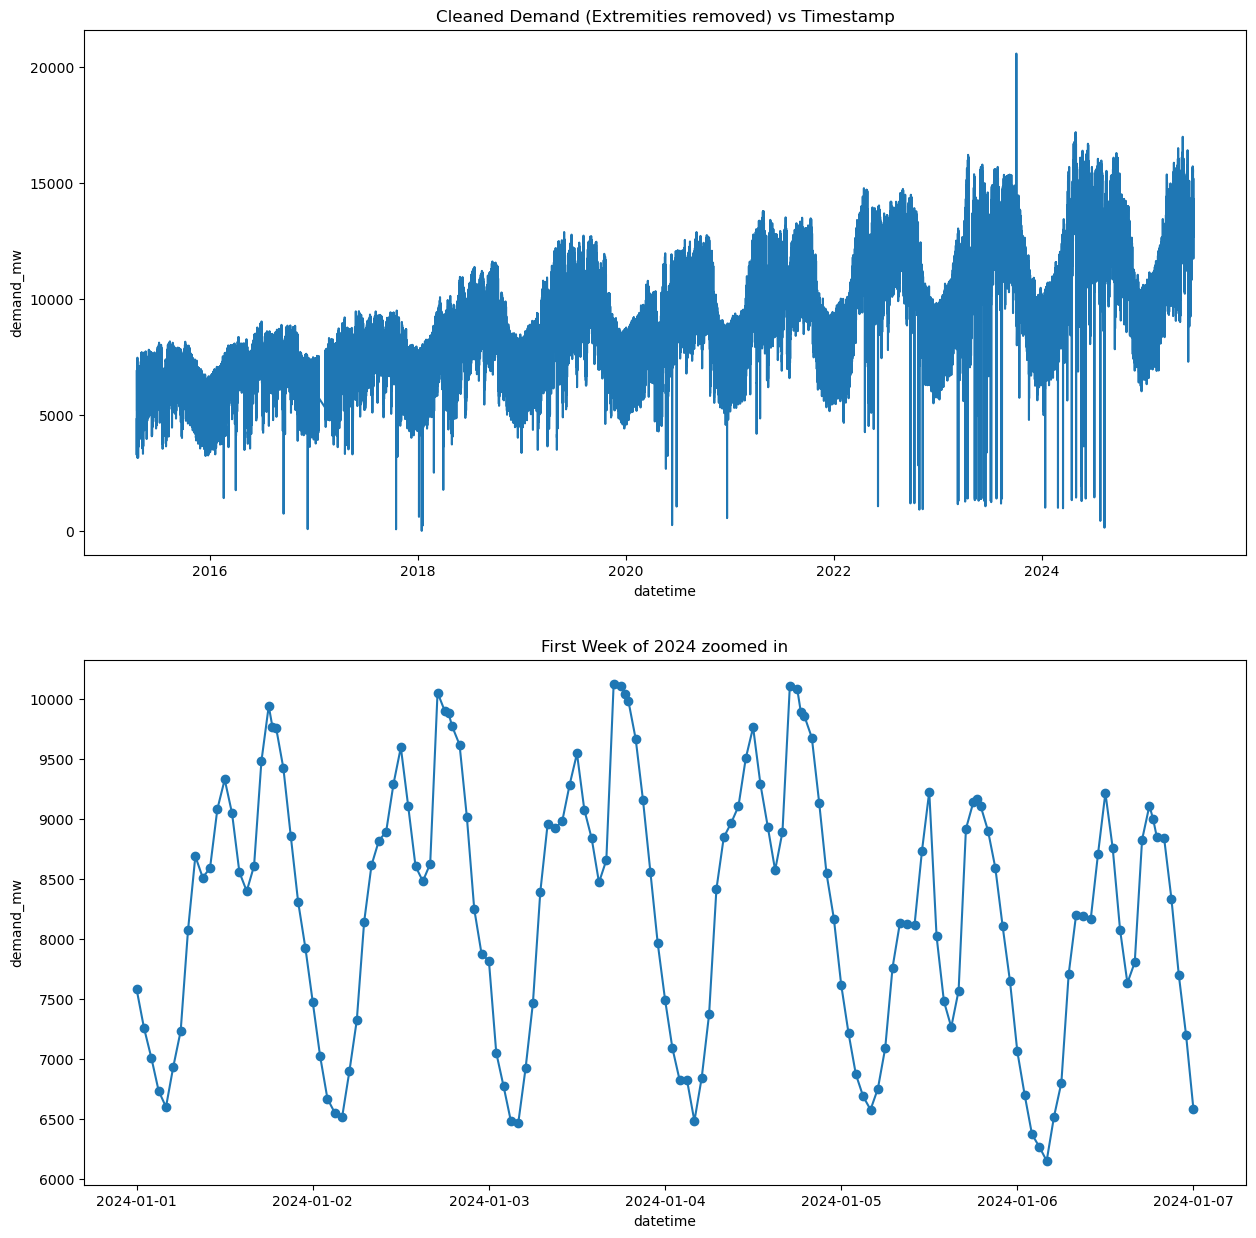

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_excel("PGCB_date_power_demand.xlsx")
df['datetime']=pd.to_datetime(df['datetime'])
df = df.sort_values('datetime') 

print("Duplicate timestamps : ",df['datetime'].duplicated().sum())
print("Missing values : ",df['demand_mw'].isnull().sum())
df=df.drop_duplicates(subset='datetime')


threshold = 25000
df_smooth=df.copy()
df_smooth.loc[df_smooth['demand_mw']>threshold,'demand_mw']=None
df_smooth['demand_mw']=df_smooth['demand_mw'].interpolate(method='linear')

start='2024-01-01'
end='2024-01-07'
weekly=df_smooth[(df_smooth['datetime']>=start)&(df_smooth['datetime']<=end)]

plt.figure(figsize=(15,15))
plt.subplot(2,1,1)
x=df_smooth["datetime"]
y=df_smooth["demand_mw"]
plt.plot(x,y)
plt.xlabel("datetime")
plt.ylabel("demand_mw")
plt.title("Cleaned Demand (Extremities removed) vs Timestamp")


plt.subplot(2,1,2)
x=weekly["datetime"]
y=weekly["demand_mw"]
plt.plot(x,y,marker='o')
plt.xlabel("datetime")
plt.ylabel("demand_mw")
plt.title("First Week of 2024 zoomed in")



In [17]:
#Merging economic csv file and weather data using left join, choosing significant economic and weather factors that affect power demand using a heatmap.

Years available in given dataset= :  [2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025]
First 5 rows of master data
             datetime  generation_mw  demand_mw  load_shedding  gas  \
0 2015-04-19 00:00:00         4821.0     4821.0              0    0   
1 2015-04-19 01:00:00         3612.0     3612.0              0    0   
2 2015-04-19 02:00:00         3727.0     3727.0              0    0   
3 2015-04-19 03:00:00         3632.0     3632.0              0    0   
4 2015-04-19 04:00:00         3641.0     3641.0              0    0   

   liquid_fuel  coal  hydro  solar  wind  ...  apparent_temperature (°C)  \
0            0     0      0    NaN   NaN  ...                       29.6   
1            0     0      0    NaN   NaN  ...                       30.0   
2            0     0      0    NaN   NaN  ...                       29.6   
3            0     0      0    NaN   NaN  ...                       29.3   
4            0     0      0    NaN   NaN  ...                       30.

<Figure size 640x480 with 0 Axes>

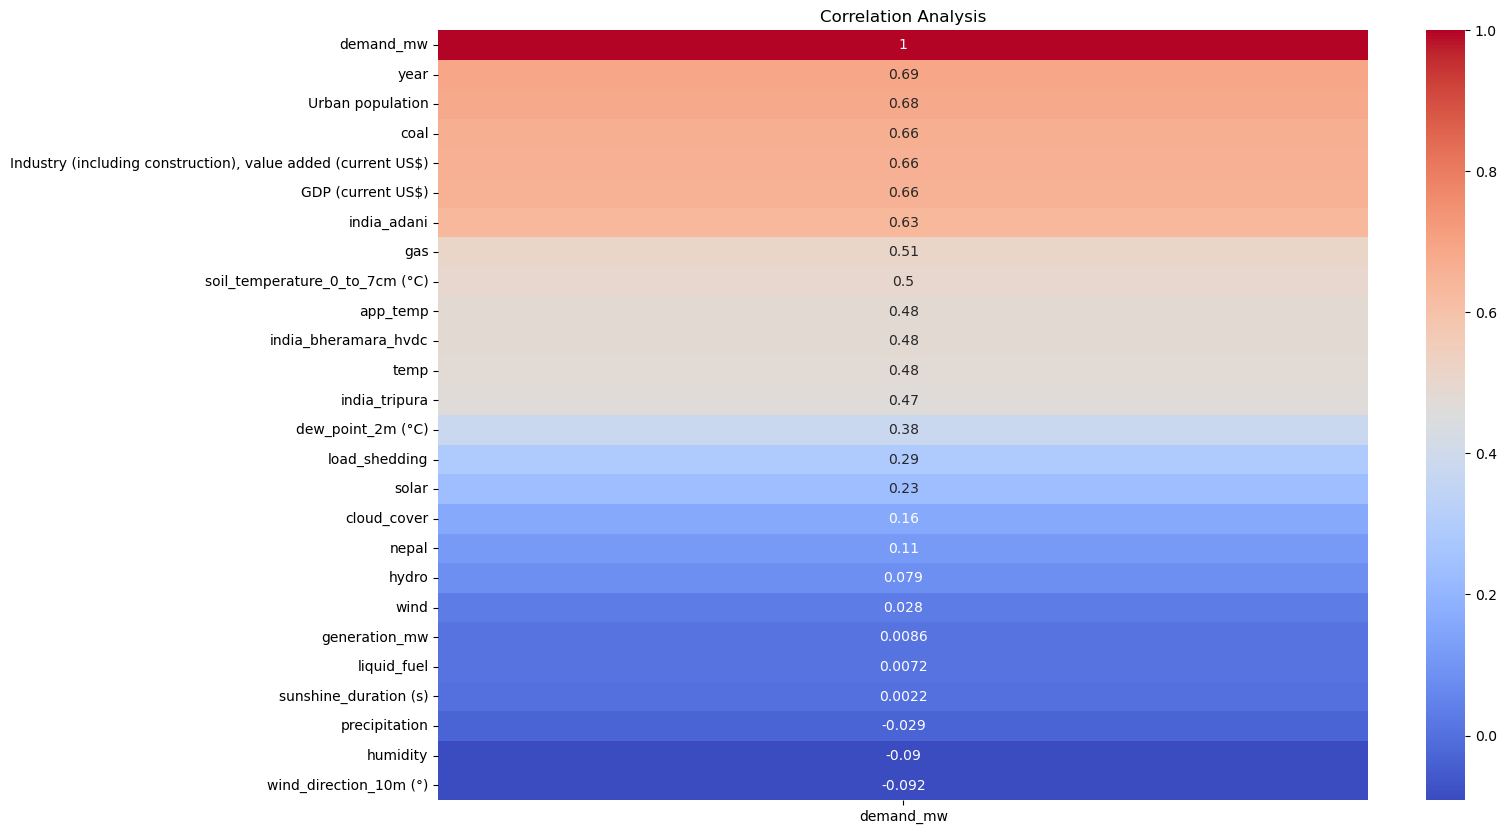

In [3]:
wf=pd.read_excel("weather_data.xlsx",skiprows=3)
wf=wf.rename(columns={'time':'datetime'})
wf['datetime']=pd.to_datetime(wf['datetime'])

ef=pd.read_csv("economic_full_1.csv")
indicators = [
    "Urban population",
    "GDP (current US$)",
    "Industry (including construction), value added (current US$)"]   #chosen by me
e_filtered=ef[ef['Indicator Name'].isin(indicators)]

e_long=e_filtered.melt(
    id_vars=['Indicator Name'],
    var_name='year',
    value_name='value'
)

e_long['year']=pd.to_numeric(e_long['year'],errors='coerce')
e_long=e_long.dropna(subset=['year'])
e_long['year']=e_long['year'].astype(int) #
e_new=e_long.pivot(index='year',columns='Indicator Name',values='value').reset_index()  #

df_smooth['year']=df_smooth['datetime'].dt.year

dwf=pd.merge(df_smooth,wf,on='datetime',how='left')

master=pd.merge(dwf,e_new,on='year',how='left')

print("Years available in given dataset= : ",master['year'].unique())
master=master[master['year']>=2015]

print("First 5 rows of master data")
print(master.head())

print("Missing values per column")
print(master.isnull().sum())

plt.tight_layout()  #
plt.show()

rename = {
    'temperature_2m (°C)': 'temp',
    'relative_humidity_2m (%)': 'humidity',
    'apparent_temperature (°C)': 'app_temp',
    'precipitation (mm)': 'precipitation',
    'cloud_cover (%)': 'cloud_cover'
}
master=master.rename(columns=rename)

econ_cols=["GDP (current US$)","Urban population","Industry (including construction), value added (current US$)"]
master[econ_cols]=master[econ_cols].apply(pd.to_numeric,errors='coerce')  #why numeric

weather_cols=['temp','humidity','app_temp','precipitation','cloud_cover']
master[weather_cols]=master[weather_cols].apply(pd.to_numeric,errors='coerce')

import seaborn as sb
corr=master.corr(numeric_only=True)
main_drivers=corr[['demand_mw']].sort_values(by='demand_mw',ascending=False)
plt.figure(figsize=(15,10))
sb.heatmap(main_drivers,annot=True,cmap='coolwarm')
plt.title("Correlation Analysis")
plt.show()


In [7]:
#Accessing 'datetime', Creating lags, nexthour_target and rolling means.

In [6]:
master=master.set_index('datetime')
per_range=pd.date_range(start=master.index.min(),end=master.index.max(),freq='h')
master=master.reindex(per_range)
master=master.interpolate(method='linear')
master=master.reset_index().rename(columns={'index':'datetime'})


master['hour']=master['datetime'].dt.hour
master['day']=master['datetime'].dt.dayofweek
master['month']=master['datetime'].dt.month
master['is_weeknd']=master['day'].apply(lambda x : 1 if x>=5 else 0)
master['quarter']=master['datetime'].dt.quarter

integer_cols=['hour','day','month','quarter','is_weeknd']
master[integer_cols]=master[integer_cols].astype(int)  #

master['nexthour_target']=master['demand_mw'].shift(-1)
master['1hour_lag']=master['demand_mw'].shift(1)
master['nextday_lag']=master['demand_mw'].shift(24)
master['6h_rollingmean']=master['demand_mw'].rolling(window=6).mean()
master=master.dropna(subset=['nexthour_target','1hour_lag','nextday_lag','6h_rollingmean'])

print(master[['datetime','demand_mw','1hour_lag','nexthour_target']].head())

              datetime    demand_mw    1hour_lag  nexthour_target
24 2015-04-20 00:00:00  5678.000000  6000.500000      5607.285714
25 2015-04-20 01:00:00  5607.285714  5678.000000      5536.571429
26 2015-04-20 02:00:00  5536.571429  5607.285714      5465.857143
27 2015-04-20 03:00:00  5465.857143  5536.571429      5395.142857
28 2015-04-20 04:00:00  5395.142857  5465.857143      5324.428571


/var/folders/zv/bj58jd5x1yggqm5q9srphpvh0000gn/T/ipykernel_43372/2137746421.py:4: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  master=master.interpolate(method='linear')


In [9]:
#Creating second heatmap to see how factors affect demand at (t+1), listing top predictors for the same.

Top 10 predictors for next hour's target (t+1)
                      generation_mw  demand_mw  load_shedding       gas  \
generation_mw              1.000000   0.008437       0.002039  0.004277   
demand_mw                  0.008437   1.000000       0.288973  0.518699   
load_shedding              0.002039   0.288973       1.000000  0.075119   
gas                        0.004277   0.518699       0.075119  1.000000   
liquid_fuel                0.000023   0.006993       0.000990  0.000161   
coal                       0.007557   0.667294       0.221395  0.139536   
hydro                     -0.002141   0.084453       0.023573  0.020113   
solar                      0.000654   0.252606       0.127422 -0.026278   
wind                       0.035836   0.030817       0.000929 -0.014498   
india_bheramara_hvdc       0.005425   0.480580       0.109637  0.278897   

                      liquid_fuel      coal     hydro     solar      wind  \
generation_mw            0.000023  0.007557 -0.002

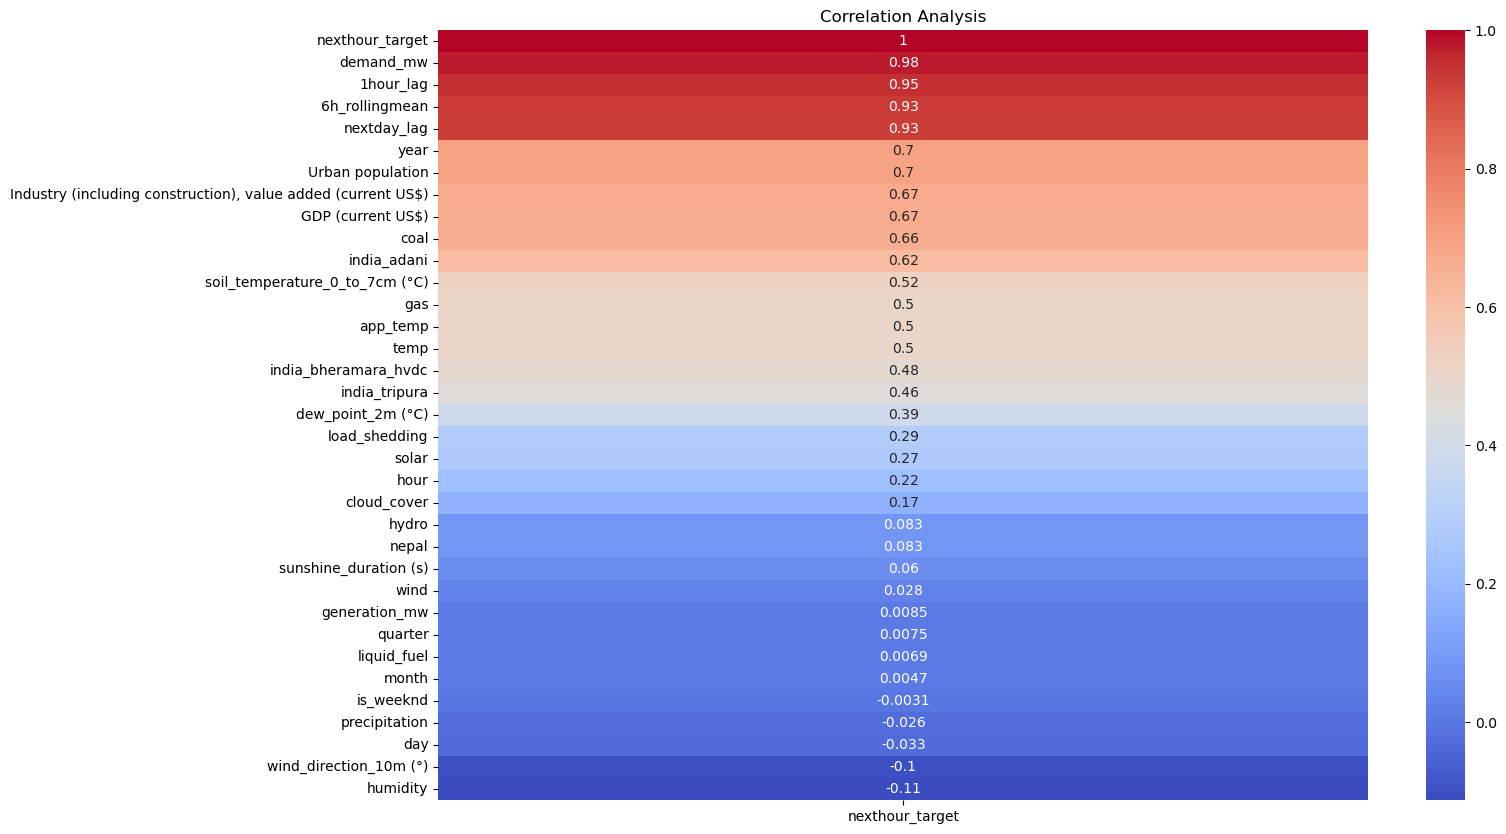

In [8]:
corr_new=master.corr(numeric_only=True)
main_drivers=corr_new[['nexthour_target']].sort_values(by='nexthour_target',ascending=False)
print("Top 10 predictors for next hour's target (t+1)")
print(corr_new.head(10))
plt.figure(figsize=(15,10))
sb.heatmap(main_drivers,annot=True,cmap='coolwarm')
plt.title("Correlation Analysis")
plt.show()



In [14]:
#Splitting data into training and testing data, training the model using Random Forest.
#I used Random Forest Regressor here since there is a non-linear relationship between the variables (like temperature) and  power demand.

In [19]:
training_data = master[master['datetime']<='2023-12-31']
test_data=master[master['datetime']>='2024-01-01']
features = ['hour','day','month','is_weeknd','quarter','1hour_lag','nextday_lag','6h_rollingmean','temp','app_temp','humidity','GDP (current US$)','Urban population','Industry (including construction), value added (current US$)']
x_training=training_data[features]
y_training=training_data['nexthour_target']
x_test=test_data[features]
y_test=test_data['nexthour_target']

print("Training size : ",x_training.shape[0],"hours")
print("Testing size : ",x_test.shape[0],"hours")

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score,mean_absolute_percentage_error

model=RandomForestRegressor(random_state=37,n_jobs=-1)
model.fit(x_training,y_training)
predictions=model.predict(x_test)



Training size :  76249 hours
Testing size :  12804 hours


In [22]:
#Calculating and displaying MAE, R^2 score and displaying final comparison plot to check the forecasting accuracy.

In [ ]:
#The calculated MAPE value is around 4.65%. 
#Interpretation : An MAPE under 5% hor hourly-power forecasting is considered to be very accurate, showing that the model can forecast the power demand in a considerably reliable manner.

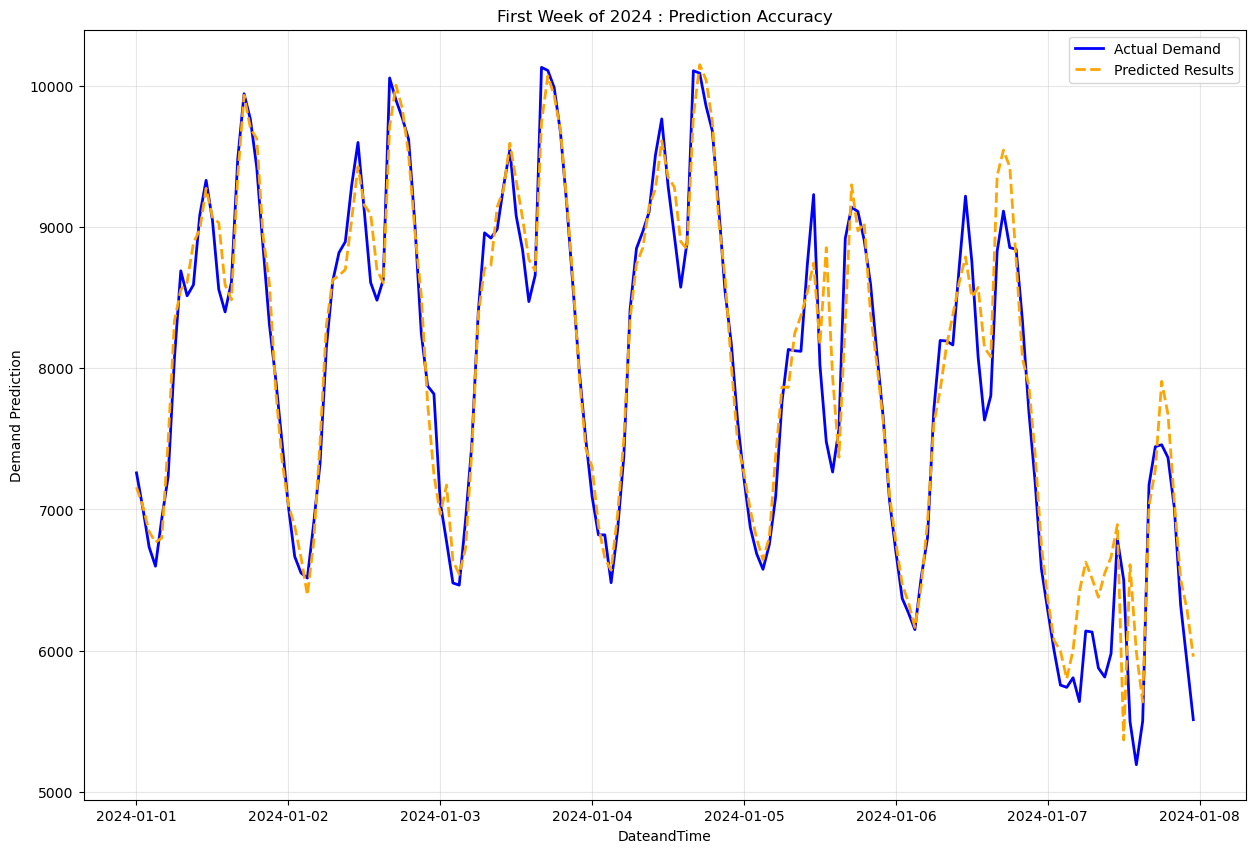

RESULTS
Mean absolute error :  364.3164939347156 MW
R2 Score :  0.9356706733579871
MAPE:  4.655812787566764 %


In [23]:
m=mean_absolute_error(y_test,predictions)
r=r2_score(y_test,predictions)
mape=mean_absolute_percentage_error(y_test,predictions)*100


final_df=pd.DataFrame({
    'DateandTime':test_data['datetime'],
    'ExpectedResults':y_test,
    'Predictions':predictions
    })

test_week=final_df.head(24*7)

plt.figure(figsize=(15,10))
plt.plot(test_week['DateandTime'],test_week['ExpectedResults'],label='Actual Demand',color='blue',linewidth=2)
plt.plot(test_week['DateandTime'],test_week['Predictions'],label='Predicted Results',color='orange',linestyle='--',linewidth=2)
plt.title("First Week of 2024 : Prediction Accuracy")
plt.xlabel("DateandTime")
plt.ylabel("Demand Prediction")
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()


print("RESULTS")
print("Mean absolute error : ",m,"MW")
print("R2 Score : ",r)
print("MAPE: ",mape,"%")


